In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

In [2]:
data = torchvision.datasets.MNIST(root='./data', train=True, download=True)

In [3]:
import torchvision.datasets as dataset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [4]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,),(0.3081,))
    ]
)

train_set = dataset.MNIST(root = "./data", train = True, download = True, transform = transform)
test_set = dataset.MNIST(root = "./data", train = False, download = True, transform = transform)

train_loader = DataLoader(train_set, batch_size = 64, shuffle=True)
test_loader  = DataLoader(test_set, batch_size = 64, shuffle=True)

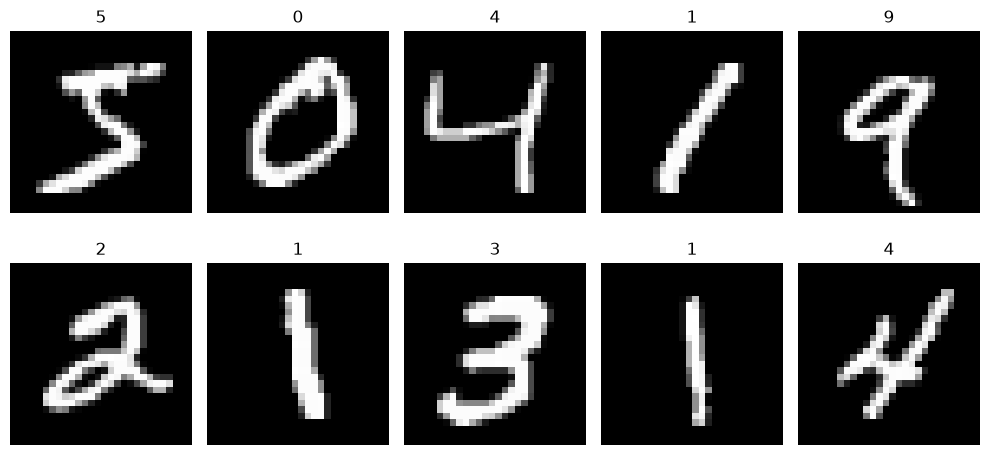

In [5]:
## Visuals
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(10):
    image, label = train_set[i]

    axes[i//5, i%5].imshow(image.squeeze(), cmap="gray")
    axes[i//5, i%5].set_title(label)
    axes[i//5, i%5].axis("off")

plt.tight_layout()
plt.savefig("sample_digits.png", dpi = 300, bbox_inches='tight')
plt.show()

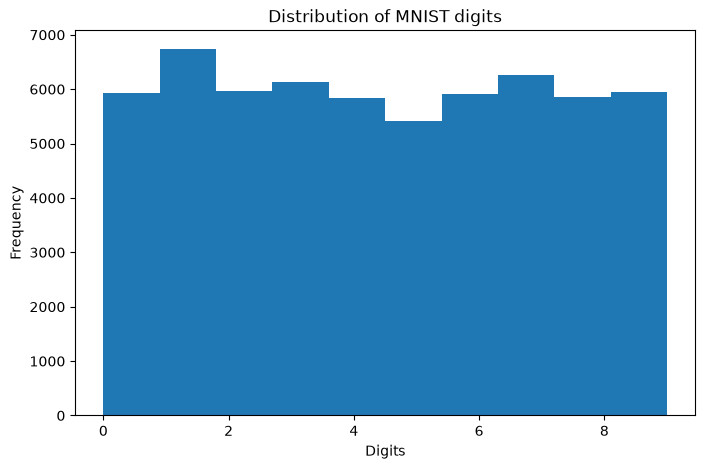

In [6]:
labels = train_set.targets
plt.figure(figsize = (8,5))
plt.hist(labels, bins = 10)
plt.xlabel("Digits")
plt.ylabel("Frequency")
plt.title("Distribution of MNIST digits")
plt.savefig("dataset_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
image, label = train_set[0]

print(image.shape)
print(label)

torch.Size([1, 28, 28])
5


## CNN

In [8]:
# Building CNN
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    # Convolutional + pooling layer
    self.conv_layer = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size = 3, padding=1),  # initial_channel = 1 , no. of kernals = 32
        nn.ReLU(),
        nn.MaxPool2d(2,2),   # kernal_size = 2, # stride = 2  

        nn.Conv2d(32, 64, kernel_size = 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(64, 128, kernel_size = 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(128, 256, kernel_size = 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.fc_layer = nn.Sequential(
        nn.Linear(256*1*1, 350),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(350, 10)
    )

  def forward(self, x):
     x = self.conv_layer(x)
     x = x.view(x.size(0), -1)    # flattening
     x  = self.fc_layer(x)
     return x

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters())

In [10]:
# Trainning and Evaluation 
epochs = 30
train_loss = []
test_loss = []
patience = 5
best_loss = float('inf')
counter = 0

for epoch in range(epochs):
  cnn_model.train()
  running_tloss = 0.0

  for images, labels in train_loader:

    optimizer.zero_grad()

    images = images.to(device)
    labels = labels.to(device)

    output = cnn_model.forward(images)
    loss = criterion(output, labels)
    loss.backward()   # back propagation
    optimizer.step()  # update parameters

    running_tloss += loss.item()

  training_loss = running_tloss/len(train_loader)
  train_loss.append(training_loss)

  # validation
  cnn_model.eval()
  running_vloss = 0.0

  with torch.no_grad():

    for images, labels in test_loader:

      images = images.to(device)
      labels = labels.to(device)
        
      output = cnn_model(images)
      loss = criterion(output, labels)

      running_vloss += loss.item()

    validation_loss = running_vloss/len(test_loader)
    test_loss.append(validation_loss)

  
  print(f"Epoch {epoch+1}/{epochs} Training Loss : {training_loss}  Validation Loss : {validation_loss}")
  if best_loss>validation_loss:
    best_loss = validation_loss
    torch.save(cnn_model.state_dict(), "cnn_best_model.pth")
    counter = 0
  else:
    counter += 1
    print(f"No Improvement... counter {counter}")
    if counter >= patience:
      print(f"Early Stopping...... ")
      break

Epoch 1/30 Training Loss : 0.17935172229685556  Validation Loss : 0.03881829564391404
Epoch 2/30 Training Loss : 0.0500855990818941  Validation Loss : 0.038461945982127904
Epoch 3/30 Training Loss : 0.03558687732067468  Validation Loss : 0.04072219464400706
No Improvement... counter 1
Epoch 4/30 Training Loss : 0.02789462266716535  Validation Loss : 0.03266464559718463
Epoch 5/30 Training Loss : 0.02524340005665683  Validation Loss : 0.027885837048456402
Epoch 6/30 Training Loss : 0.020149540026977775  Validation Loss : 0.02990590082064483
No Improvement... counter 1
Epoch 7/30 Training Loss : 0.016498097870929256  Validation Loss : 0.0378643229256604
No Improvement... counter 2
Epoch 8/30 Training Loss : 0.014993903471401641  Validation Loss : 0.04311492637741608
No Improvement... counter 3
Epoch 9/30 Training Loss : 0.01434257612682161  Validation Loss : 0.03475141206865466
No Improvement... counter 4
Epoch 10/30 Training Loss : 0.013233742750555826  Validation Loss : 0.0319830665702

In [11]:
cnn_model.load_state_dict(torch.load("cnn_best_model.pth"))

<All keys matched successfully>

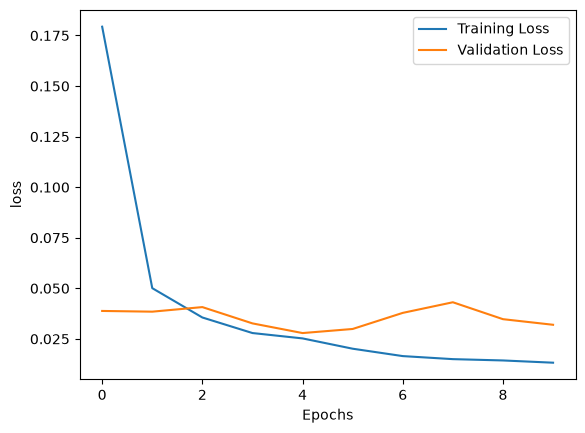

In [12]:

df = pd.DataFrame(
    {
        "Training Loss" : train_loss,
        "Validation Loss" : test_loss
    }
)

plt.plot(df["Training Loss"], label = "Training Loss")
plt.plot(df["Validation Loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.legend()
plt.savefig("cnn_loss_graph.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [13]:
results = {}
def save_results(model_name):
    results[model_name] = {
        "Accuracy" : accuracy,
        "Confusion Matrix" : con_matrix,
        "classification report" : classif_report
    }

Accuracy : 99.21%
[[ 976    0    0    0    1    0    2    1    0    0]
 [   0 1131    0    0    0    1    0    3    0    0]
 [   0    1 1026    0    1    0    1    2    1    0]
 [   0    1    2  993    0    9    0    4    1    0]
 [   0    0    0    0  976    0    0    0    1    5]
 [   0    0    0    2    0  888    1    1    0    0]
 [   1    2    0    0    1    1  953    0    0    0]
 [   0    3    3    0    1    0    0 1020    0    1]
 [   0    0    1    0    0    2    1    0  969    1]
 [   0    0    0    0    9    3    0    2    6  989]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      1.00      0.99       892
           6       0.99      0.99      0.99       958
           7      

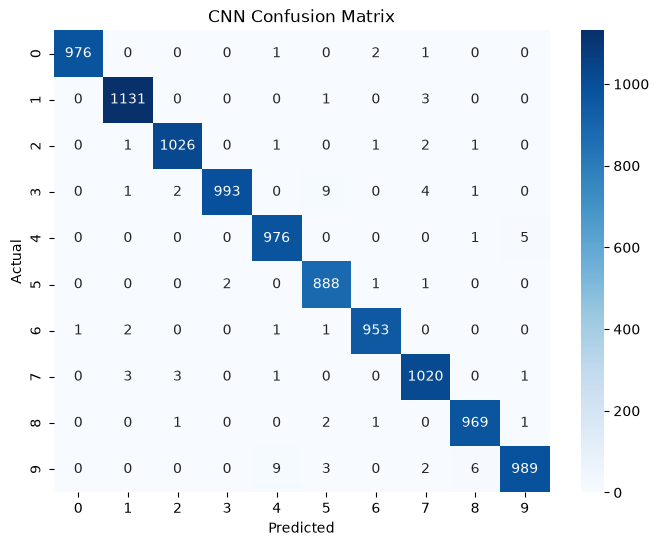

In [14]:
from sklearn.metrics import confusion_matrix, classification_report

correct_label = 0
total_label = 0

all_labels = []
all_predictions = []

cnn_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)

        output = cnn_model(images)
        predicted = torch.argmax(output, dim=1)

        total_label += labels.size(0)
        correct_label += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = correct_label / total_label
print(f"Accuracy : {accuracy*100:.2f}%")

con_matrix = confusion_matrix(all_labels, all_predictions)
print(con_matrix)

classif_report = classification_report(all_labels, all_predictions)
print(classif_report)

save_results("CNN")

# visuals
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    con_matrix,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.savefig("cnn_confusion_matrix_heatmap.png", dpi = 300, bbox_inches = "tight")
plt.show()

## RNN

In [15]:
# Building RNN

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size = 128, num_layers = 2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers= num_layers
    
        # RNN Layer
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first = True)
    
        # fc layer
        self.fc = nn.Linear(hidden_size, 10)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [16]:
input_size = 28
rnn_model = RNN(input_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn_model.parameters())

In [17]:
# Training
epochs = 30
rnn_train_loss = []
rnn_test_loss = []
rnn_patience = 5
rnn_counter = 0
rnn_best_loss = float('inf')

for epoch in range(epochs):
    rnn_model.train()
    rnn_running_tloss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        images = images.squeeze(1)

        output = rnn_model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        rnn_running_tloss += loss.item()

    rnn_training_loss = rnn_running_tloss/len(train_loader)
    rnn_train_loss.append(rnn_training_loss)

    # validation
    rnn_model.eval()
    rnn_running_vloss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            images = images.squeeze(1)
            
            output = rnn_model(images)
            loss = criterion(output, labels)

            rnn_running_vloss += loss.item()

        rnn_validation_loss = rnn_running_vloss/len(test_loader)
        rnn_test_loss.append(rnn_validation_loss)


        print(f"epoch {epoch + 1}/{epochs} Training Loss : {rnn_training_loss:.4f}  Validation Loss : {rnn_validation_loss:.4f}")

        if rnn_best_loss > rnn_validation_loss:
            rnn_best_loss = rnn_validation_loss
            rnn_counter = 0
            torch.save(rnn_model.state_dict(), "rnn_best_model.pth")

        else:
            rnn_counter+=1
            print(f"No Improvement   counter {rnn_counter}")
            if rnn_counter >= rnn_patience:
                print("Early Stopping.....")
                break


epoch 1/30 Training Loss : 0.5652  Validation Loss : 0.2331
epoch 2/30 Training Loss : 0.2209  Validation Loss : 0.1599
epoch 3/30 Training Loss : 0.1668  Validation Loss : 0.1676
No Improvement   counter 1
epoch 4/30 Training Loss : 0.1475  Validation Loss : 0.1260
epoch 5/30 Training Loss : 0.1358  Validation Loss : 0.1375
No Improvement   counter 1
epoch 6/30 Training Loss : 0.1193  Validation Loss : 0.1700
No Improvement   counter 2
epoch 7/30 Training Loss : 0.1117  Validation Loss : 0.1113
epoch 8/30 Training Loss : 0.1073  Validation Loss : 0.1154
No Improvement   counter 1
epoch 9/30 Training Loss : 0.1053  Validation Loss : 0.1152
No Improvement   counter 2
epoch 10/30 Training Loss : 0.1308  Validation Loss : 0.2081
No Improvement   counter 3
epoch 11/30 Training Loss : 0.1129  Validation Loss : 0.1174
No Improvement   counter 4
epoch 12/30 Training Loss : 0.1115  Validation Loss : 0.1292
No Improvement   counter 5
Early Stopping.....


In [18]:
rnn_model.load_state_dict(torch.load("rnn_best_model.pth"))

<All keys matched successfully>

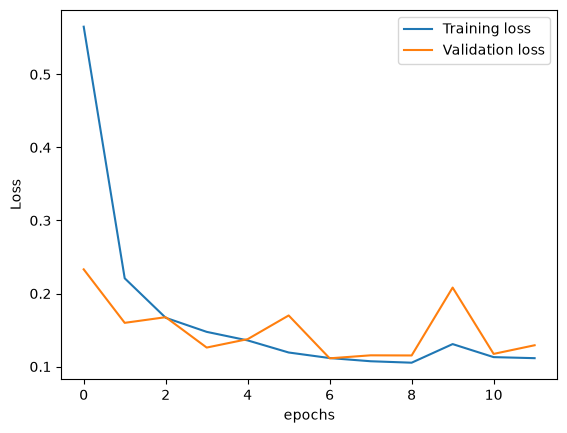

In [19]:
# visuals
rnn_df = pd.DataFrame(
    {
        "Training Loss" : rnn_train_loss,
        "Validation Loss" : rnn_test_loss
    }
)

plt.plot(rnn_df["Training Loss"], label = "Training loss")
plt.plot(rnn_df["Validation Loss"], label = "Validation loss")
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("rnn_loss_graph.png", dpi = 300, bbox_inches = "tight")
plt.show()

Accuracy : 96.87%
[[ 961    0    1    0    0    4   10    2    2    0]
 [   0 1114    4    8    3    1    0    2    3    0]
 [   1    4 1012    4    1    0    1    5    4    0]
 [   0    1    4  989    0   11    0    3    0    2]
 [   0    1    3    0  965    0    0    1    0   12]
 [   0    2    1   13    1  863    5    3    0    4]
 [  11    4    4    0   17    3  915    0    4    0]
 [   0    3    8    2    2    2    0 1000    0   11]
 [   1    3    3    3    6    6    7    4  927   14]
 [   0    2    3   17   29    7    0    8    2  941]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.98      0.98      0.98      1135
           2       0.97      0.98      0.98      1032
           3       0.95      0.98      0.97      1010
           4       0.94      0.98      0.96       982
           5       0.96      0.97      0.96       892
           6       0.98      0.96      0.97       958
           7      

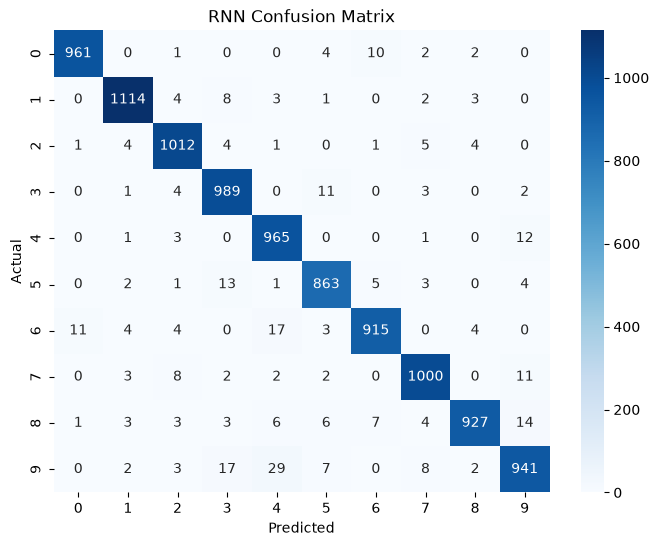

In [20]:
# Evaluation
rnn_correct_label = 0
rnn_total_label = 0

rnn_all_labels = []
rnn_all_predictions = []

rnn_model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)
        
        images = images.squeeze(1)

        output = rnn_model(images)
        predicted = torch.argmax(output, dim=1)

        rnn_total_label += labels.size(0)
        rnn_correct_label += (predicted == labels).sum().item()

        rnn_all_labels.extend(labels.cpu().numpy())
        rnn_all_predictions.extend(predicted.cpu().numpy())

accuracy = rnn_correct_label / rnn_total_label
print(f"Accuracy : {accuracy*100:.2f}%")

con_matrix = confusion_matrix(rnn_all_labels, rnn_all_predictions)
print(con_matrix)

classif_report = classification_report(rnn_all_labels, rnn_all_predictions)
print(classif_report)

save_results("RNN")
# visuals

plt.figure(figsize=(8,6))

sns.heatmap(
    con_matrix,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RNN Confusion Matrix")
plt.savefig("rnn_confusion_matrix_heatmap.png")
plt.show()

In [21]:
Results = pd.DataFrame(results)
Results.to_csv("Comparision_table.csv", index=True)